/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/150 — Train MSE: 478.8151
Epoch 2/150 — Train MSE: 76.9999
Epoch 3/150 — Train MSE: 71.3895
Epoch 4/150 — Train MSE: 65.4559
Epoch 5/150 — Train MSE: 62.7806
Epoch 6/150 — Train MSE: 56.8609
Epoch 7/150 — Train MSE: 54.3925
Epoch 8/150 — Train MSE: 54.2380
Epoch 9/150 — Train MSE: 50.4426
Epoch 10/150 — Train MSE: 51.2796
Epoch 11/150 — Train MSE: 47.6301
Epoch 12/150 — Train MSE: 50.4923
Epoch 13/150 — Train MSE: 46.3160
Epoch 14/150 — Train MSE: 48.8819
Epoch 15/150 — Train MSE: 45.0708
Epoch 16/150 — Train MSE: 43.3745
Epoch 17/150 — Train MSE: 45.4619
Epoch 18/150 — Train MSE: 39.3654
Epoch 19/150 — Train MSE: 42.3754
Epoch 20/150 — Train MSE: 36.6134
Epoch 21/150 — Train MSE: 36.5728
Epoch 22/150 — Train MSE: 38.1712
Epoch 23/150 — Train MSE: 35.3594
Epoch 24/150 — Train MSE: 33.1673
Epoch 25/150 — Train MSE: 32.8333
Epoch 26/150 — Train MSE: 25.0610
Epoch 27/150 — Train MSE: 27.4522
Epoch 28/150 — Train MSE: 23.0368
Epoch 29/150 — Train MSE: 21.5901
Epoch 30/150 — Train M

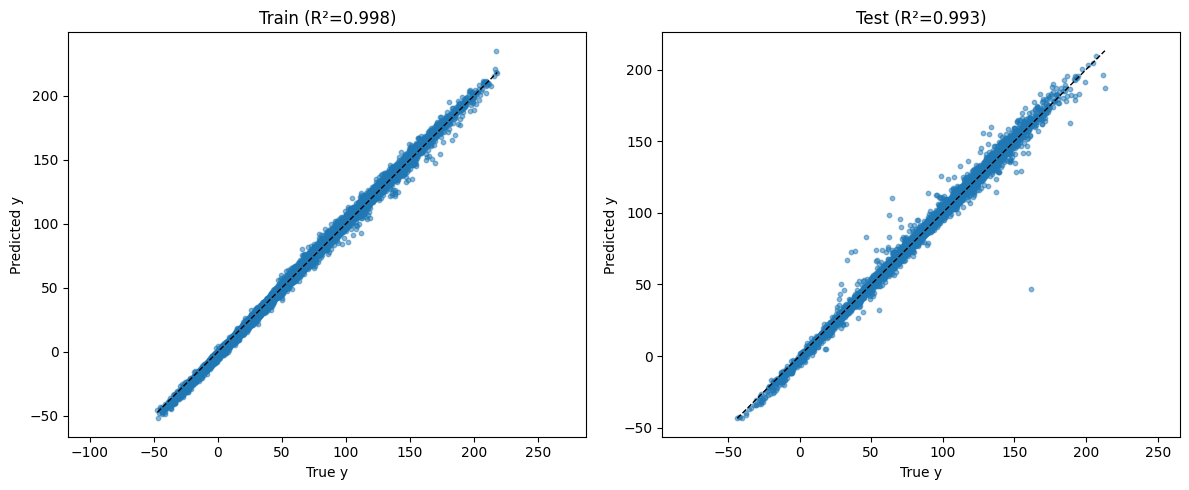

Model state_dict saved to regressor_state.pth


In [ ]:
########################################################
##            1) Surrogate (Regression)              ###
########################################################
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# -------------------------
# A) Hyperparameters & Data
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
lr = 1e-3
epochs = 150

# Load data
xs_train = np.load('./xs_train.npy')  # shape (N_train, 192, 2)
ys_train = np.load('./ys_train.npy')
xs_test  = np.load('./xs_test.npy')   # shape (N_test, 192, 2)
ys_test  = np.load('./ys_test.npy')

# Convert to PyTorch Tensors
# We interpret the input as [B, 1, H, W], so let's treat "192" as height and "2" as width
X_train = torch.tensor(xs_train, dtype=torch.float32).unsqueeze(1)  # => [N,1,192,2]
y_train = torch.tensor(ys_train, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(xs_test,  dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(ys_test,  dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)

# -------------------------
# B) Define ResNet-18 Regressor
# -------------------------
Regmodel = models.resnet18(pretrained=False)

# Adapt the first conv layer from (7x7) to (7x1) + 1-channel input
Regmodel.conv1 = nn.Conv2d(1, 64, kernel_size=(7,1), stride=(2,1), padding=(3,0), bias=False)

# Replace final FC for 1D regression
Regmodel.fc = nn.Linear(Regmodel.fc.in_features, 1)

Regmodel = Regmodel.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(Regmodel.parameters(), lr=lr)

# -------------------------
# C) Training Loop
# -------------------------
for epoch in range(1, epochs + 1):
    Regmodel.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = Regmodel(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    train_mse = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch}/{epochs} — Train MSE: {train_mse:.4f}")

# -------------------------
# D) Evaluation
# -------------------------
def get_preds(loader):
    Regmodel.eval()
    ys_true, ys_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            p = Regmodel(xb).cpu().numpy().ravel()
            ys_pred.append(p)
            ys_true.append(yb.numpy().ravel())
    return np.concatenate(ys_true), np.concatenate(ys_pred)

y_train_true, y_train_pred = get_preds(train_loader)
y_test_true,  y_test_pred  = get_preds(test_loader)

r2_train = r2_score(y_train_true, y_train_pred)
r2_test  = r2_score(y_test_true,  y_test_pred)
print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")

# -------------------------
# E) Plot True vs. Pred
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (true, pred, title) in zip(
    axes,
    [
        (y_train_true, y_train_pred, f"Train (R²={r2_train:.3f})"),
        (y_test_true,  y_test_pred,  f"Test (R²={r2_test:.3f})")
    ]
):
    ax.scatter(true, pred, alpha=0.5, s=10)
    mn, mx = true.min(), true.max()
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
    ax.set_title(title)
    ax.set_xlabel("True y")
    ax.set_ylabel("Predicted y")
    ax.axis("equal")

plt.tight_layout()
plt.show()
save_path = 'regressor_state.pth'
torch.save(Regmodel.state_dict(), save_path)
print(f"Model state_dict saved to {save_path}")

[Epoch 1/200] Loss: 0.046149
[Epoch 2/200] Loss: 0.010036
[Epoch 3/200] Loss: 0.008591
[Epoch 4/200] Loss: 0.007855
[Epoch 5/200] Loss: 0.007312
[Epoch 6/200] Loss: 0.006738
[Epoch 7/200] Loss: 0.006389
[Epoch 8/200] Loss: 0.006008
[Epoch 9/200] Loss: 0.005806
[Epoch 10/200] Loss: 0.005609
[Epoch 11/200] Loss: 0.005093
[Epoch 12/200] Loss: 0.004465
[Epoch 13/200] Loss: 0.004367
[Epoch 14/200] Loss: 0.004183
[Epoch 15/200] Loss: 0.004151
[Epoch 16/200] Loss: 0.004072
[Epoch 17/200] Loss: 0.003964
[Epoch 18/200] Loss: 0.004036
[Epoch 19/200] Loss: 0.003899
[Epoch 20/200] Loss: 0.003972
[Epoch 21/200] Loss: 0.003822
[Epoch 22/200] Loss: 0.003793
[Epoch 23/200] Loss: 0.003744
[Epoch 24/200] Loss: 0.003728
[Epoch 25/200] Loss: 0.003656
[Epoch 26/200] Loss: 0.003642
[Epoch 27/200] Loss: 0.003659
[Epoch 28/200] Loss: 0.003660
[Epoch 29/200] Loss: 0.003599
[Epoch 30/200] Loss: 0.003591
[Epoch 31/200] Loss: 0.003554
[Epoch 32/200] Loss: 0.003616
[Epoch 33/200] Loss: 0.003490
[Epoch 34/200] Loss

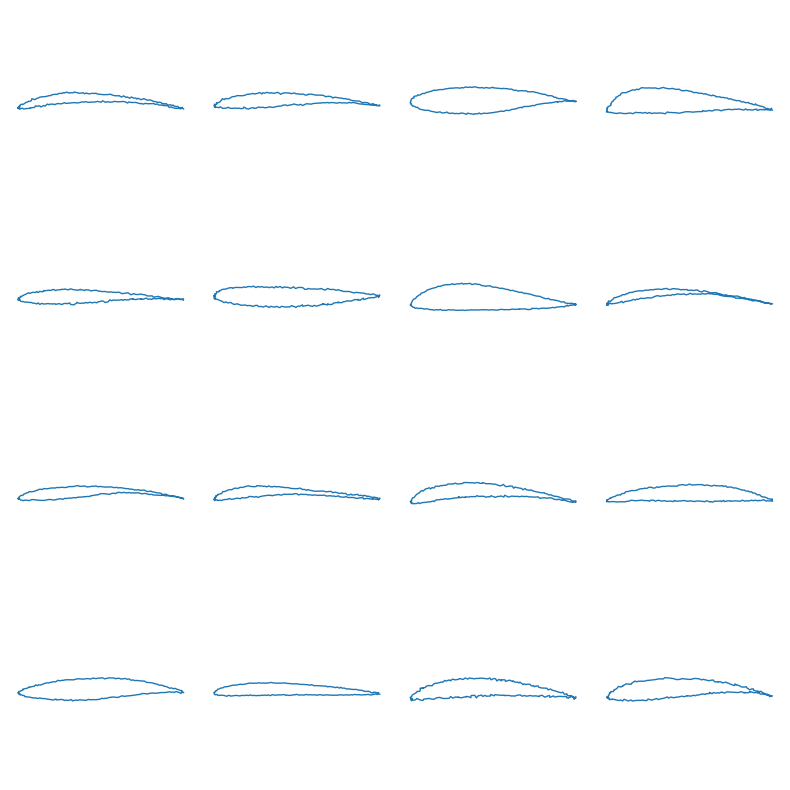

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

########################################################
##               Diffusion Hyperparams               ##
########################################################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_timesteps = 1000
batch_size = 64
lr = 1e-3
epochs = 200

########################################################
##                   Load Data                       ##
########################################################
# shape (N,192,2) => we reshape to (N,2,192)
xs_train = np.load("./xs_train.npy")    # Must be shape (N,192,2)
xs_test  = np.load("./xs_test.npy")

# concatenate along axis 0 (rows / samples)
xs_train = np.concatenate([xs_train, xs_test], axis=0)

X = torch.tensor(xs_train.transpose(0,2,1), dtype=torch.float32)  # => (N,2,192)

ds = TensorDataset(X)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

########################################################
##               Cosine Beta-Schedule                ##
########################################################
def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine schedule from https://arxiv.org/abs/2102.09672
    """
    steps = timesteps
    x = torch.linspace(0, steps, steps + 1, dtype=torch.float64)
    alphas_cum = torch.cos(((x / steps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cum = alphas_cum / alphas_cum[0]
    betas = 1.0 - (alphas_cum[1:] / alphas_cum[:-1])
    return betas.to(torch.float32).clamp(0.0001, 0.9999)

betas = cosine_beta_schedule(num_timesteps).to(device)
alphas = 1.0 - betas
alphas_cum = torch.cumprod(alphas, dim=0)
sqrt_alphas_cum = torch.sqrt(alphas_cum)
sqrt_one_minus_alphas_cum = torch.sqrt(1.0 - alphas_cum)

########################################################
##                    Time Embedding                  ##
########################################################
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / half)
        args = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

########################################################
##               1D Building Blocks                   ##
########################################################
class ResidualBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, groups=8):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.gn1   = nn.GroupNorm(groups, out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.gn2   = nn.GroupNorm(groups, out_ch)
        self.skip  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        h = self.conv1(x)
        h = self.gn1(h)
        h = F.silu(h)
        h = self.conv2(h)
        h = self.gn2(h)
        return self.skip(x) + h

class Downsample1D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv1d(ch, ch, 4, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class Upsample1D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.tconv = nn.ConvTranspose1d(ch, ch, 4, stride=2, padding=1)
    def forward(self, x):
        return self.tconv(x)

########################################################
##                Self-Attention Block                ##
########################################################
class SelfAttention1D(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.mha  = nn.MultiheadAttention(embed_dim=channels, num_heads=num_heads)
        self.norm = nn.LayerNorm(channels)
    def forward(self, x):
        B, C, L = x.size()
        x_seq = x.permute(2, 0, 1)
        attn_out, _ = self.mha(x_seq, x_seq, x_seq)
        attn_out = self.norm(attn_out)
        return x + attn_out.permute(1, 2, 0)

########################################################
##                     UNet1D                         ##
########################################################
class UNet1D(nn.Module):
    def __init__(self, in_ch=2, base_ch=64, time_emb_dim=128):
        super().__init__()
        # time embedding
        self.time_emb = TimeEmbedding(time_emb_dim)
        self.time_mlp1 = nn.Sequential(nn.Linear(time_emb_dim, base_ch),   nn.SiLU())
        self.time_mlp2 = nn.Sequential(nn.Linear(time_emb_dim, base_ch*2), nn.SiLU())
        self.time_mlp3 = nn.Sequential(nn.Linear(time_emb_dim, base_ch*4), nn.SiLU())
        self.time_mlp4 = nn.Sequential(nn.Linear(time_emb_dim, base_ch*2), nn.SiLU())
        self.time_mlp5 = nn.Sequential(nn.Linear(time_emb_dim, base_ch),   nn.SiLU())

        # encoder
        self.block1 = ResidualBlock1D(in_ch, base_ch)
        self.attn1  = SelfAttention1D(base_ch)
        self.down1  = Downsample1D(base_ch)

        self.block2 = ResidualBlock1D(base_ch, base_ch*2)
        self.attn2  = SelfAttention1D(base_ch*2)
        self.down2  = Downsample1D(base_ch*2)

        self.block3 = ResidualBlock1D(base_ch*2, base_ch*4)
        self.attn3  = SelfAttention1D(base_ch*4)

        # decoder
        self.up1    = Upsample1D(base_ch*4)
        self.block4 = ResidualBlock1D(base_ch*4 + base_ch*2, base_ch*2)
        self.attn4  = SelfAttention1D(base_ch*2)

        self.up2    = Upsample1D(base_ch*2)
        self.block5 = ResidualBlock1D(base_ch*2 + base_ch, base_ch)
        self.attn5  = SelfAttention1D(base_ch)

        self.out    = nn.Conv1d(base_ch, in_ch, 3, padding=1)

    def forward(self, x, t):
        temb = self.time_emb(t)
        t1 = self.time_mlp1(temb).unsqueeze(-1)
        t2 = self.time_mlp2(temb).unsqueeze(-1)
        t3 = self.time_mlp3(temb).unsqueeze(-1)
        t4 = self.time_mlp4(temb).unsqueeze(-1)
        t5 = self.time_mlp5(temb).unsqueeze(-1)

        # encoder
        h1 = self.block1(x) + t1
        h1 = self.attn1(h1)
        d1 = self.down1(h1)

        h2 = self.block2(d1) + t2
        h2 = self.attn2(h2)
        d2 = self.down2(h2)

        h3 = self.block3(d2) + t3
        h3 = self.attn3(h3)

        # decoder
        u1  = self.up1(h3)
        cat1= torch.cat([u1, h2], dim=1)
        h4  = self.block4(cat1) + t4
        h4  = self.attn4(h4)

        u2  = self.up2(h4)
        cat2= torch.cat([u2, h1], dim=1)
        h5  = self.block5(cat2) + t5
        h5  = self.attn5(h5)

        return self.out(h5)

########################################################
##                q_sample (Forward)                  ##
########################################################
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrtAC = sqrt_alphas_cum[t].view(-1,1,1)
    sqrtOM = sqrt_one_minus_alphas_cum[t].view(-1,1,1)
    return sqrtAC * x0 + sqrtOM * noise, noise

########################################################
##               Training Setup                      ##
########################################################
model = UNet1D().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
mse_loss = nn.MSELoss()

########################################################
##               Training Loop                       ##
########################################################
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    for (x0_batch,) in dl:
        x0 = x0_batch.to(device)
        B  = x0.size(0)
        t  = torch.randint(0, num_timesteps, (B,), device=device).long()
        x_t, noise = q_sample(x0, t)
        noise_pred = model(x_t, t)
        loss = mse_loss(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * B
    print(f"[Epoch {epoch}/{epochs}] Loss: {total_loss/len(dl.dataset):.6f}")

########################################################
##        Reverse Diffusion (Sampling)               ##
########################################################
@torch.no_grad()
def p_sample(model, x, t):
    beta_t = betas[t]
    alpha_t = 1.0 - beta_t
    sqrt_alpha_t = torch.sqrt(alpha_t)
    coef = (1 - alpha_t) / torch.sqrt(1 - alphas_cum[t])
    eps_pred = model(x, torch.full((x.size(0),), t, device=x.device, dtype=torch.long))
    mean = (1.0 / sqrt_alpha_t) * (x - coef * eps_pred)
    if t > 0:
        z = torch.randn_like(x)
        sigma_t = torch.sqrt(beta_t)
        return mean + sigma_t * z
    return mean

@torch.no_grad()
def sample(model, n_samples=16):
    x = torch.randn(n_samples, 2, 192, device=device)
    for i in reversed(range(num_timesteps)):
        x = p_sample(model, x, i)
    return x

########################################################
##            Generate & Plot Samples                ##
########################################################
samples = sample(model, 16).cpu().numpy()
fig, axs = plt.subplots(4,4, figsize=(8,8))
for ax, s in zip(axs.flatten(), samples):
    pts = s.T
    ax.plot(pts[:,0], pts[:,1], lw=1)
    ax.axis('equal'); ax.axis('off')
plt.tight_layout()
plt.show()

torch.save(model.state_dict(), "diffusion_unet1d_multiscale_attn.pt")


In [ ]:
# Load *trained* weights (skip if you’re continuing in-memory):

#model.load_state_dict(torch.load("diffusion_unet1d.pt"))
#model.eval()                       # important for RWMLE stability

#Regmodel.load_state_dict(torch.load("surrogate_resnet18.pt"))

Regmodel.eval()

# --- Schedules that are already in memory ---

sqrt_alphas_cum          = torch.sqrt(alphas_cum)               # [T]
sqrt_one_minus_alphas_cum = torch.sqrt(1.0 - alphas_cum)        # [T]

def get_alpha_bar(t_idx):
    """
    Vectorised lookup of  \bar α_t  with shape [B,1,1]  for broadcasting
    """
    a_bar = alphas_cum[t_idx].view(-1, 1, 1)          # (B,1,1)
    return a_bar.clamp_min(1e-8)

@torch.no_grad()
def objective_function(x):                            # x : (B,2,192)
    """
    Predict scalar reward with the frozen ResNet-18 surrogate.
    """
    x_sur = x.permute(0, 2, 1).unsqueeze(1)           # -> (B,1,192,2)
    y_hat = Regmodel(x_sur.to(device))                # (B,1)
    return y_hat.squeeze(1)                           # (B,)


In [ ]:
samples = sample(model, 1000).cpu().numpy()

In [ ]:
# ——————————————————————————————————————————————————————————————
# 1) Generate samples
# ——————————————————————————————————————————————————————————————
# 'sample' is your reverse‐diffusion sampler defined earlier,
# which returns a torch.Tensor of shape (n_samples, 2, 192).
n_samples = 1300
samples = sample(model, n_samples=n_samples)   # torch.Tensor on device

# ——————————————————————————————————————————————————————————————
# 2) Compute rewards
# ——————————————————————————————————————————————————————————————
# 'objective_function' expects a torch.Tensor input and returns a torch.Tensor of shape (n_samples,)
rewards_tensor = objective_function(samples)    # torch.Tensor on device

# (Optional) move to CPU / NumPy if you need to inspect or save:
samples_np = samples.cpu().numpy()
rewards = rewards_tensor.cpu().numpy()

print(f"Samples shape: {samples_np.shape}")
print(f"Rewards shape: {rewards.shape}")
print(f"Reward stats: min={rewards.min()}, mean={rewards.mean()}, max={rewards.max()}")


Samples shape: (1300, 2, 192)
Rewards shape: (1300,)
Reward stats: min=-47.095882415771484, mean=61.29738998413086, max=182.54689025878906


In [ ]:
import pandas as pd
pd.DataFrame({"reward": rewards}).to_csv("rewards_ddpmAirfoild_noopt.csv", index=False)


In [ ]:
raw_rewards = objective_function(samples).cpu().numpy()

# ——————————————————————————————————————————————————————————————
# 4) Save to CSV
# ——————————————————————————————————————————————————————————————
df = pd.DataFrame({
    "raw_reward": raw_rewards})
csv_filename = "simple_sampling_rewards.csv"
df.to_csv(csv_filename, index=False)
print(f"Saved raw+clean rewards to '{csv_filename}'")

# ——————————————————————————————————————————————————————————————
# 6) Plot top‑20 high‑reward airfoils
# ——————————————————————————————————————————————————————————————
# only consider finite values
finite_idx = np.where(np.isfinite(raw_rewards))[0]
if len(finite_idx) == 0:
    print("No finite rewards to plot.")
else:
    top20 = finite_idx[np.argsort(raw_rewards[finite_idx])[-20:][::-1]]
    samples_np = samples.cpu().numpy()  # (N,2,192)

    plt.figure(figsize=(10,6))
    for i in top20:
        x_vals, y_vals = samples_np[i]
        plt.plot(x_vals, y_vals, alpha=0.6)
    plt.title("Top 20 High‑Reward Airfoil Designs")
    plt.xlabel("x-coordinate")
    plt.ylabel("y-coordinate")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'permute'

In [ ]:
import time
import torch
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import FileLink

# ——————————————————————————————————————————————————————————————
# 1) Set up device and your model & objective
# ——————————————————————————————————————————————————————————————
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
start_time = time.time()
# — Replace these with your actual model & surrogate function —
# model: a DDPM‐style model where eps_pred = model(x_t, t_vec)
# objective_function: takes x0 (batch x dims) and returns a (batch,) tensor of rewards
# e.g.:
# model = YourDDPMModel(...).to(device)
# def objective_function(x0):
#     return your_surrogate(x0)

# ——————————————————————————————————————————————————————————————
# 2) Move diffusion schedule to device
# ——————————————————————————————————————————————————————————————
betas = betas.to(device)                   # shape: (T,)
alphas = 1.0 - betas                       # shape: (T,)
alphas_cum = torch.cumprod(alphas, dim=0)  # shape: (T,)
sqrt_alphas_cum = torch.sqrt(alphas_cum)
sqrt_one_minus_alphas_cum = torch.sqrt(1.0 - alphas_cum)
num_timesteps = betas.shape[0]

# ——————————————————————————————————————————————————————————————
# 3) Define the SVDD sampler with M proposals per particle
# ——————————————————————————————————————————————————————————————
@torch.no_grad()
def svdd_sample(model,
                objective_fn,
                num_particles: int = 500,
                M: int = 10,
                eps_floor: float = 1e-8):
    """
    SVDD sampling: at each reverse step, propose M candidates per particle,
    weight by predicted reward, and select one.
    """
    # Initialize particles at t = T
    x_t = torch.randn(num_particles, 2, 192, device=device)

    for t in reversed(range(1, num_timesteps + 1)):
        t_idx = t - 1

        # 1) Compute reverse‐diffusion mean & sigma
        beta_t = betas[t_idx]
        alpha_t = 1.0 - beta_t
        a_bar_t = alphas_cum[t_idx]
        coeff1 = 1.0 / torch.sqrt(alpha_t)
        coeff2 = (1.0 - alpha_t) / torch.sqrt(1.0 - a_bar_t)

        t_vec = torch.full((num_particles,), t, dtype=torch.long, device=device)
        noise_pred = model(x_t, t_vec)               # (N, 2, 192)
        mean_prev = coeff1 * (x_t - coeff2 * noise_pred)

        if t > 1:
            prev_a = alphas_cum[t_idx - 1]
            beta_hat = (1.0 - prev_a) / (1.0 - a_bar_t) * beta_t
            sigma = torch.sqrt(beta_hat)
        else:
            sigma = 0.0

        # 2) Propose M candidates per particle
        mean_exp = mean_prev.unsqueeze(1).expand(-1, M, -1, -1)   # (N, M, 2, 192)
        noise = torch.randn_like(mean_exp) * sigma
        candidates = mean_exp + noise                             # (N, M, 2, 192)

        # 3) Flatten for denoising & scoring
        flat_cand = candidates.reshape(num_particles * M, 2, 192)
        if t_idx > 0:
            t0_vec = torch.full((flat_cand.size(0),), t_idx,
                                dtype=torch.long, device=device)
            eps_cand = model(flat_cand, t0_vec)
            x0_pred = ((flat_cand
                        - sqrt_one_minus_alphas_cum[t_idx - 1] * eps_cand)
                       / sqrt_alphas_cum[t_idx - 1])
        else:
            x0_pred = flat_cand

        rewards = objective_fn(x0_pred) \
                    .clamp_min(eps_floor) \
                    .view(num_particles, M)

        # 4) Select one candidate per particle proportional to its reward
        choice = torch.multinomial(rewards, 1).squeeze(1)          # (N,)
        x_t = candidates[torch.arange(num_particles), choice]      # (N, 2, 192)

    return x_t

# ——————————————————————————————————————————————————————————————
# 4) Run SVDD sampling & collect rewards
# ——————————————————————————————————————————————————————————————
num_particles = 1000
M = 5
samples = svdd_sample(model, objective_function,
                      num_particles=num_particles,
                      M=M)
rewards = objective_function(samples).cpu().numpy()

print(f"Generated {samples.shape[0]} samples; reward stats:",
      rewards.min(), rewards.mean(), rewards.max())

# ——————————————————————————————————————————————————————————————
# 5) Plot the top‑20 high‑reward airfoil designs
# ——————————————————————————————————————————————————————————————
samples_np = samples.cpu().numpy()  # (N, 2, 192)
top20_idx = rewards.argsort()[-20:][::-1]
end_time = time.time()
total_time = end_time - start_time
print(f"time {total_time})")
plt.figure(figsize=(10, 6))
for i in top20_idx:
    x_vals, y_vals = samples_np[i]
    plt.plot(x_vals, y_vals, alpha=0.6)
plt.title("Top 20 High‑Reward Airfoil Designs (SVDD)")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.grid(True)
plt.tight_layout()
plt.show()

# ——————————————————————————————————————————————————————————————
# 6) Save samples + rewards to CSV and provide download link
# ——————————————————————————————————————————————————————————————
# Flatten each (2,192) into a row of length 384
flat_samples = samples_np.reshape(samples_np.shape[0], -1)
columns = [f"coord_{i}" for i in range(flat_samples.shape[1])]
df = pd.DataFrame(flat_samples, columns=columns)
df["reward"] = rewards

csv_path = "svdd_samples_rewards.csv"
df.to_csv(csv_path, index=False)

# In Jupyter you can click the link below to download:
FileLink(csv_path)

NameError: name 'betas' is not defined

In [ ]:
rewards.max()

np.float32(175.37617)

In [ ]:
import torch
import matplotlib.pyplot as plt  # ← make sure to import

# ——————————————————————————————————————————————————————————————
# 1) Set up device and import your model & objective
# ——————————————————————————————————————————————————————————————
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume you have these already:
#   model             # your DDPM-style model: ε_pred = model(x_t, t_vec)
#   objective_function(x0)  # surrogate that returns a (batch,) tensor of rewards

# ——————————————————————————————————————————————————————————————
# 2) Define your diffusion schedule (or move existing globals to device)
# ——————————————————————————————————————————————————————————————
betas = betas.to(device)                  # shape: (T,)
alphas = 1.0 - betas                      # shape: (T,)
alphas_cum = torch.cumprod(alphas, dim=0) # shape: (T,)
sqrt_alphas_cum = torch.sqrt(alphas_cum)
sqrt_one_minus_alphas_cum = torch.sqrt(1.0 - alphas_cum)
num_timesteps = betas.shape[0]

# ——————————————————————————————————————————————————————————————
# 3) Define the SMC sampler
# ——————————————————————————————————————————————————————————————
@torch.no_grad()
def smc_sample(model,
               objective_fn,
               num_particles: int = 500,
               eps_floor: float   = 1e-8):
    # initialize particles at t = T
    x_t = torch.randn(num_particles, 2, 192, device=device)
    weights = torch.ones(num_particles, device=device) / num_particles

    def predict_x0(x, t_idx: int):
        if t_idx == 0:
            return x
        t_vec = torch.full((x.size(0),), t_idx, dtype=torch.long, device=device)
        eps   = model(x, t_vec)
        return (x - sqrt_one_minus_alphas_cum[t_idx-1] * eps) \
               / sqrt_alphas_cum[t_idx-1]

    for t in reversed(range(1, num_timesteps + 1)):
        # reverse diffusion step
        beta_t     = betas[t-1]
        alpha_t    = alphas[t-1]
        a_bar_t    = alphas_cum[t-1]

        coeff1     = 1.0 / torch.sqrt(alpha_t)
        coeff2     = (1.0 - alpha_t) / torch.sqrt(1.0 - a_bar_t)
        noise_pred = model(x_t,
                           torch.full((x_t.size(0),), t,
                                      dtype=torch.long, device=device))
        mean_prev  = coeff1 * (x_t - coeff2 * noise_pred)

        if t > 1:
            prev_a   = alphas_cum[t-2]
            beta_hat = (1.0 - prev_a) / (1.0 - a_bar_t) * beta_t
            sigma    = torch.sqrt(beta_hat)
        else:
            sigma = torch.zeros_like(beta_t)

        x_t = mean_prev + sigma * torch.randn_like(x_t)

        # weight by predicted reward & resample
        x0_pred = predict_x0(x_t, t-1)
        rewards = objective_fn(x0_pred).clamp_min(eps_floor)
        weights = weights * rewards
        weights = weights / weights.sum()

        idx = torch.multinomial(weights, num_particles, replacement=True)
        x_t = x_t[idx]
        weights = torch.ones_like(weights) / num_particles

    return x_t

# ——————————————————————————————————————————————————————————————
# 4) Run SMC sampling and collect rewards
# ——————————————————————————————————————————————————————————————
samples = smc_sample(model, objective_function, num_particles=12000)
rewards = objective_function(samples).cpu().numpy()

print(f"Generated {samples.shape[0]} samples; reward stats:",
      rewards.min(), rewards.mean(), rewards.max())

# ——————————————————————————————————————————————————————————————
# 5) Plot the top-20 high-reward airfoil designs
# ——————————————————————————————————————————————————————————————
# Convert to NumPy for indexing
samples_np = samples.cpu().numpy()  # shape: (N, 2, 192)

# Get indices of top-20 rewards
top20_idx = rewards.argsort()[-20:][::-1]  # descending order

# Plot all 20 on one figure
plt.figure(figsize=(10, 6))
for i in top20_idx:
    coords = samples_np[i]       # shape (2, 192)
    x_vals, y_vals = coords[0], coords[1]
    plt.plot(x_vals, y_vals, alpha=0.6)

plt.title("Top 20 High-Reward Airfoil Designs")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import torch
import pandas as pd
import numpy as np

# assume `samples` is your tensor of shape (N, 2, 192)
# and `rewards` is a NumPy array of shape (N,)
samples_np = samples.cpu().numpy()            # (N, 2, 192)
N = samples_np.shape[0]

# reshape to (N, 384): first all x-coords, then y-coords
flat_samples = samples_np.reshape(N, -1)      # (N, 384)

# stack rewards as final column
data = np.concatenate([flat_samples, rewards.reshape(-1, 1)], axis=1)  # (N, 385)

# create column names
x_cols = [f"x{i}" for i in range(192)]
y_cols = [f"y{i}" for i in range(192)]
cols   = x_cols + y_cols + ["reward"]

# build DataFrame and save
df = pd.DataFrame(data, columns=cols)
df.to_csv("samples_with_rewards.csv", index=False)

print("Saved samples_and_rewards.csv with", N, "rows and", df.shape[1], "columns.")


In [ ]:
samples = smc_sample(model, objective_function, num_particles=500)
rewards = objective_function(samples).cpu().numpy()


In [ ]:
rewards.max()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def reward_weighted_mle_fine_tune_for_svdd(
    model,
    objective_fn,
    num_trajectories=32,
    alpha=1.0,             # temperature for softmax
    steps=500,
    lr=1e-4,
    max_grad_norm=1.0,
    reward_clip=(-50, 50),
    device='cuda',
):
    """
    Stabilized Reward-Weighted MLE fine-tuning for SVDD sampling:
      - Normalizes advantages
      - Uses softmax for weights
      - Clips rewards and gradients
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps)
    mse_loss  = nn.MSELoss(reduction='none')

    for step in range(1, steps+1):
        # (A) Sample full reverse trajectories
        x_t = torch.randn(num_trajectories, 2, 192, device=device)
        noise_preds = []
        noises      = []

        for t in reversed(range(1, num_timesteps+1)):
            t_vec = torch.full((num_trajectories,), t, dtype=torch.long, device=device)
            pred  = model(x_t, t_vec)
            noise_preds.append(pred)

            β = betas[t-1]
            α_t = 1.0 - β
            ā  = alphas_cum[t-1]
            coeff1 = 1.0 / torch.sqrt(α_t)
            coeff2 = (1.0 - α_t) / torch.sqrt(1.0 - ā)
            mean_prev = coeff1 * (x_t - coeff2 * pred)

            if t > 1:
                ā_prev = alphas_cum[t-2]
                β_hat  = β * (1 - ā_prev) / (1 - ā)
                std_prev = torch.sqrt(β_hat).to(device)
            else:
                std_prev = torch.zeros_like(mean_prev)

            noise = torch.randn_like(x_t)
            noises.append(noise)
            x_t = mean_prev + std_prev * noise

        # (B) Compute and normalize advantages
        x0 = x_t
        rewards = objective_fn(x0).detach().clamp(*reward_clip)      # (N,)
        adv = rewards - rewards.mean()
        std = rewards.std(unbiased=False).clamp_min(1e-6)
        adv = adv / std

        # (C) Softmax weights
        weights = torch.softmax(adv / (alpha + 1e-8), dim=0)                  # (N,)

        # (D) Build weighted MSE loss across all steps
        # stack per-step MSEs to [T, N]
        per_step_mse = []
        for pred, noise in zip(noise_preds, noises):
            mse = mse_loss(pred, noise)                              # (N,2,192)
            mse = mse.view(num_trajectories, -1).mean(dim=1)         # (N,)
            per_step_mse.append(mse)
        losses = torch.stack(per_step_mse, dim=0)                   # (T, N)
        loss_per_traj = losses.sum(dim=0)                           # (N,)
        total_loss = (weights * loss_per_traj).sum()                # scalar

        # (E) Backward & clip
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()


        print(f"[RWMLE] step {step}/{steps} — loss {total_loss.item():.4f}, "
                  f"mean rew {rewards.mean().item():.4f}")

    print(f"[RWMLE] Finished {steps} steps. Final loss: {total_loss.item():.4f}")


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def reward_weighted_mle_fine_tune_for_svdd(
    model,
    objective_fn,
    num_trajectories=32,
    alpha=1.0,            # controls sharpness of weighting
    steps=500,            # number of fine-tuning gradient steps
    lr=1e-4,              # learning rate
    clamp_exp=1e1,        # clamp for exp to avoid overflow
    baseline_val=0.0      # reward baseline
):
    """
    Reward-weighted MLE fine-tuning:
      1) Sample `num_trajectories` full reverse trajectories x_T→…→x_0.
      2) For each trajectory, record (noise_pred, actual_noise) at every step.
      3) Compute final reward r(x_0) and weights w_i = exp((r_i−baseline_val)/alpha), clamped.
      4) Form a weighted MSE loss over all steps:
           L = Σ_i w_i · [ Σ_{t=1}^T MSE(noise_pred_{i,t}, noise_{i,t}) ].
      5) Backpropagate and update model to minimize L.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    mse_loss  = nn.MSELoss(reduction='none')

    for step in range(steps):
        # (A) Collect full reverse trajectories
        x_t = torch.randn(num_trajectories, 2, 192, device=device)
        all_noise_preds = []   # list of [num_trajectories×2×192]
        all_noises      = []   # same shape

        for t in reversed(range(1, num_timesteps+1)):
            t_vec      = torch.full((num_trajectories,), t, dtype=torch.long, device=device)
            noise_pred = model(x_t, t_vec)                         # (N,2,192)
            all_noise_preds.append(noise_pred)

            # compute posterior mean/std for reverse step
            β_t      = betas[t-1]
            α_t      = 1.0 - β_t
            ā_t      = alphas_cum[t-1]
            coeff1   = 1.0 / torch.sqrt(α_t)
            coeff2   = (1.0 - α_t) / torch.sqrt(1.0 - ā_t)
            mean_prev = coeff1 * (x_t - coeff2 * noise_pred)

            if t > 1:
                ā_prev   = alphas_cum[t-2]
                β̂_t      = β_t * (1 - ā_prev) / (1 - ā_t)
                std_prev = torch.sqrt(β̂_t)
            else:
                std_prev = torch.zeros_like(β_t)

            noise = torch.randn_like(x_t)
            all_noises.append(noise)
            x_t = mean_prev + std_prev * noise

        # (B) Compute rewards & importance weights
        x0      = x_t
        rewards = objective_fn(x0).detach()                      # (N,)
        weights = torch.exp((rewards - baseline_val) / (alpha+ 1e-8))    # (N,)
        weights = torch.clamp(weights, max=clamp_exp)
        weights = weights / weights.sum()

        # (C) Build weighted MSE loss across all steps
        total_loss = 0.0
        for noise_pred, noise in zip(all_noise_preds, all_noises):
            # per-sample MSE:
            mse_per_sample = mse_loss(noise_pred, noise)           # (N,2,192)
            mse_per_sample = mse_per_sample.view(num_trajectories, -1).mean(dim=1)
            total_loss    += (mse_per_sample * weights).sum()


        print(f"[RWMLE] step={step+1}/{steps}, Loss={total_loss.item():.4f}, "
                  f"MeanReward={rewards.mean().item():.4f}")

        # (D) Gradient step
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

    print(f"[rwmle] completed {steps} fine-tuning steps. final loss: {total_loss.item():.4f}")


In [ ]:
reward_weighted_mle_fine_tune_for_svdd(
    model,
    objective_function,
    num_trajectories=6,
    alpha= 0.8,
    steps=1000,
    lr=5e-5,
    baseline_val=10.0
)


TypeError: reward_weighted_mle_fine_tune_for_svdd() got an unexpected keyword argument 'baseline_val'

In [ ]:
reward_weighted_mle_fine_tune_for_svdd(
    model=model,
    objective_fn=objective_function,
    num_trajectories=4,
    alpha=0.8,
    steps=100,
    lr=5e-5,
    max_grad_norm=0.5,
    reward_clip=(-10, 200),
    device=device,
)

[RWMLE] step 1/100 — loss 1990.6593, mean rew 68.1297
[RWMLE] step 2/100 — loss 1970.8326, mean rew 44.8682
[RWMLE] step 3/100 — loss 1989.9836, mean rew 63.3931
[RWMLE] step 4/100 — loss 1964.8391, mean rew 32.4811
[RWMLE] step 5/100 — loss 1960.0862, mean rew 59.7372
[RWMLE] step 6/100 — loss 1975.0831, mean rew 24.7662
[RWMLE] step 7/100 — loss 1933.6614, mean rew 32.1302
[RWMLE] step 8/100 — loss 1941.3096, mean rew 13.4817
[RWMLE] step 9/100 — loss 1922.0291, mean rew 22.9649
[RWMLE] step 10/100 — loss 1924.1866, mean rew 33.4335
[RWMLE] step 11/100 — loss 1886.5773, mean rew 8.4195
[RWMLE] step 12/100 — loss 1966.0171, mean rew -2.4961
[RWMLE] step 13/100 — loss 1908.5662, mean rew 12.2257
[RWMLE] step 14/100 — loss 1884.4160, mean rew -0.2535
[RWMLE] step 15/100 — loss 1914.1193, mean rew 11.0302
[RWMLE] step 16/100 — loss 1922.7561, mean rew 22.1267
[RWMLE] step 17/100 — loss 1875.8259, mean rew -5.1826
[RWMLE] step 18/100 — loss 1879.1134, mean rew 28.0195
[RWMLE] step 19/100 

In [ ]:
@torch.no_grad()
def svdd_sample(
        model,
        objective_fn,
        num_samples = 32,
        M           = 8,        # proposals per step
        T           = num_timesteps,
        alpha       = 0.0):      # 0 => greedy / best-of-M * in this case it's basically best of M

    x_t = torch.randn(num_samples, 2, 192, device=device)  # start at x_T

    def predict_x0(x, t_idx):
        if t_idx == 0:
            return x
        t_vec = torch.full((x.size(0),), t_idx, dtype=torch.long, device=device)
        eps   = model(x, t_vec)
        a_bar = alphas_cum[t_idx-1]
        return (x - sqrt_one_minus_alphas_cum[t_idx-1] * eps) / sqrt_alphas_cum[t_idx-1]

    for t in reversed(range(1, T + 1)):
        t_vec = torch.full((num_samples,), t, dtype=torch.long, device=device)

        # ---- propose M candidates in parallel ----
        noise_pred = model(x_t, t_vec)                            # (N,2,192)
        beta_t     = betas[t-1]
        alpha_t    = 1. - beta_t
        a_bar_t    = alphas_cum[t-1]

        coeff1     = 1.0 / torch.sqrt(alpha_t)
        coeff2     = (1. - alpha_t) / torch.sqrt(1. - a_bar_t)
        mean_xprev = coeff1 * (x_t - coeff2 * noise_pred)

        if t > 1:
            a_bar_prev = alphas_cum[t-2]
            beta_t_hat = (1. - a_bar_prev) / (1. - a_bar_t) * beta_t
            std        = torch.sqrt(beta_t_hat)
        else:
            std        = torch.zeros_like(beta_t)

        # (N,M,2,192)
        noise      = torch.randn(num_samples, M, 2, 192, device=device)
        candidates = mean_xprev.unsqueeze(1) + std * noise

        # ---- score candidates by surrogate ----
        flat_c     = candidates.view(-1, 2, 192)
        est_x0     = predict_x0(flat_c, t-1)
        values     = objective_fn(est_x0).view(num_samples, M)

        if alpha == 0.0:
            best_idx = values.argmax(dim=1)
        else:
            probs    = torch.softmax(values / alpha, dim=1)
            best_idx = torch.multinomial(probs, num_samples=1).squeeze(1)

        x_t = candidates[torch.arange(num_samples), best_idx]     # shape (N,2,192)

    return x_t                                  # final x_0 samples  (N,2,192)


In [ ]:
samples = svdd_sample(
            model,
            objective_function,
            num_samples = 1000,
            M           = 8,
            alpha       = 0.0)          # small temperature for a bit of diversity

rewards = objective_function(samples).cpu().numpy()


In [ ]:
import torch
import numpy as np
import pandas as pd
from google.colab import files

# ---------------------------------------------------
# Settings
# ---------------------------------------------------
n_draws     = 5000    # number of samples per run
n_runs      = 10        # total loops
top_k       = 10        # how many top samples to save each run
threshold   = 220       # threshold on the top‐predicted Cl/Cd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_rows = []  # will collect flattened sample + its pred

# ---------------------------------------------------
# Loop over multiple sampling runs
# ---------------------------------------------------
Regmodel.eval()
for run in range(n_runs):
    # A) Sample
    samples = sample(model, n_samples=n_draws)             # [n_draws, 2, 192]
    samples_np = samples.cpu().numpy()                     # (n_draws, 2, 192)

    # B) Prepare for surrogate
    surr_in = np.transpose(samples_np, (0,2,1))            # (n_draws,192,2)
    surr_in = surr_in[:, None, :, :]                       # (n_draws,1,192,2)
    X_surr = torch.from_numpy(surr_in.astype(np.float32)).to(device)

    # C) Predict
    with torch.no_grad():
        preds = Regmodel(X_surr).view(-1).cpu().numpy()     # (n_draws,)

    # D) Sort and select top_k
    idx_desc = np.argsort(preds)[::-1]
    best_idx = idx_desc[:top_k]
    best_pred = preds[best_idx[0]]

    # E) If the very best exceeds threshold, save all top_k
    if best_pred > threshold:
        for idx in best_idx:
            sample_vec = samples_np[idx].flatten()          # length = 2*192 = 384
            pred_val   = preds[idx]
            # one row = [feat0, feat1, …, feat383, pred]
            all_rows.append(np.concatenate([sample_vec, [pred_val]]))

# ---------------------------------------------------
# Build DataFrame and save
# ---------------------------------------------------
# column names: feat_0 … feat_383, then 'pred'
n_feats = samples_np.shape[1] * samples_np.shape[2]
feat_cols = [f'feat_{i}' for i in range(n_feats)]
df = pd.DataFrame(all_rows, columns=feat_cols + ['pred'])

# write to CSV and download
csv_filename = 'best_samples_over_threshold.csv'
df.to_csv(csv_filename, index=False)
files.download(csv_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import numpy as np
import pandas as pd
from google.colab import files

# ---------------------------------------------------
# Settings
# ---------------------------------------------------
n_draws     = 5000    # number of samples per run
n_runs      = 10        # total loops
top_k       = 10        # how many top samples to save each run
threshold   = 220       # threshold on the top‐predicted Cl/Cd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_rows = []  # will collect flattened sample + its pred

# ---------------------------------------------------
# Loop over multiple sampling runs
# ---------------------------------------------------
Regmodel.eval()
for run in range(n_runs):
    # A) Sample
    samples = sample(model, n_samples=n_draws)             # [n_draws, 2, 192]
    samples_np = samples.cpu().numpy()                     # (n_draws, 2, 192)

    # B) Prepare for surrogate
    surr_in = np.transpose(samples_np, (0,2,1))            # (n_draws,192,2)
    surr_in = surr_in[:, None, :, :]                       # (n_draws,1,192,2)
    X_surr = torch.from_numpy(surr_in.astype(np.float32)).to(device)

    # C) Predict
    with torch.no_grad():
        preds = Regmodel(X_surr).view(-1).cpu().numpy()     # (n_draws,)

    # D) Sort and select top_k
    idx_desc = np.argsort(preds)[::-1]
    best_idx = idx_desc[:top_k]
    best_pred = preds[best_idx[0]]

    # E) If the very best exceeds threshold, save all top_k
    if best_pred > threshold:
        for idx in best_idx:
            sample_vec = samples_np[idx].flatten()          # length = 2*192 = 384
            pred_val   = preds[idx]
            # one row = [feat0, feat1, …, feat383, pred]
            all_rows.append(np.concatenate([sample_vec, [pred_val]]))

# ---------------------------------------------------
# Build DataFrame and save
# ---------------------------------------------------
# column names: feat_0 … feat_383, then 'pred'
n_feats = samples_np.shape[1] * samples_np.shape[2]
feat_cols = [f'feat_{i}' for i in range(n_feats)]
df = pd.DataFrame(all_rows, columns=feat_cols + ['pred'])

# write to CSV and download
csv_filename = 'best_samples_over_threshold.csv'
df.to_csv(csv_filename, index=False)
files.download(csv_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import numpy as np
import pandas as pd
from google.colab import files

# ---------------------------------------------------
# Settings
# ---------------------------------------------------
n_draws     = 5000    # number of samples per run
n_runs      = 10        # total loops
top_k       = 10        # how many top samples to save each run
threshold   = 220       # threshold on the top‐predicted Cl/Cd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_rows = []  # will collect flattened sample + its pred

# ---------------------------------------------------
# Loop over multiple sampling runs
# ---------------------------------------------------
Regmodel.eval()
for run in range(n_runs):
    # A) Sample
    samples = sample(model, n_samples=n_draws)             # [n_draws, 2, 192]
    samples_np = samples.cpu().numpy()                     # (n_draws, 2, 192)

    # B) Prepare for surrogate
    surr_in = np.transpose(samples_np, (0,2,1))            # (n_draws,192,2)
    surr_in = surr_in[:, None, :, :]                       # (n_draws,1,192,2)
    X_surr = torch.from_numpy(surr_in.astype(np.float32)).to(device)

    # C) Predict
    with torch.no_grad():
        preds = Regmodel(X_surr).view(-1).cpu().numpy()     # (n_draws,)

    # D) Sort and select top_k
    idx_desc = np.argsort(preds)[::-1]
    best_idx = idx_desc[:top_k]
    best_pred = preds[best_idx[0]]

    # E) If the very best exceeds threshold, save all top_k
    if best_pred > threshold:
        for idx in best_idx:
            sample_vec = samples_np[idx].flatten()          # length = 2*192 = 384
            pred_val   = preds[idx]
            # one row = [feat0, feat1, …, feat383, pred]
            all_rows.append(np.concatenate([sample_vec, [pred_val]]))

# ---------------------------------------------------
# Build DataFrame and save
# ---------------------------------------------------
# column names: feat_0 … feat_383, then 'pred'
n_feats = samples_np.shape[1] * samples_np.shape[2]
feat_cols = [f'feat_{i}' for i in range(n_feats)]
df = pd.DataFrame(all_rows, columns=feat_cols + ['pred'])

# write to CSV and download
csv_filename = 'best_samples_over_threshold.csv'
df.to_csv(csv_filename, index=False)
files.download(csv_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import numpy as np
import pandas as pd
from google.colab import files

# ---------------------------------------------------
# Settings
# ---------------------------------------------------
n_draws     = 5000    # number of samples per run
n_runs      = 10        # total loops
top_k       = 10        # how many top samples to save each run
threshold   = 220       # threshold on the top‐predicted Cl/Cd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_rows = []  # will collect flattened sample + its pred

# ---------------------------------------------------
# Loop over multiple sampling runs
# ---------------------------------------------------
Regmodel.eval()
for run in range(n_runs):
    # A) Sample
    samples = sample(model, n_samples=n_draws)             # [n_draws, 2, 192]
    samples_np = samples.cpu().numpy()                     # (n_draws, 2, 192)

    # B) Prepare for surrogate
    surr_in = np.transpose(samples_np, (0,2,1))            # (n_draws,192,2)
    surr_in = surr_in[:, None, :, :]                       # (n_draws,1,192,2)
    X_surr = torch.from_numpy(surr_in.astype(np.float32)).to(device)

    # C) Predict
    with torch.no_grad():
        preds = Regmodel(X_surr).view(-1).cpu().numpy()     # (n_draws,)

    # D) Sort and select top_k
    idx_desc = np.argsort(preds)[::-1]
    best_idx = idx_desc[:top_k]
    best_pred = preds[best_idx[0]]

    # E) If the very best exceeds threshold, save all top_k
    if best_pred > threshold:
        for idx in best_idx:
            sample_vec = samples_np[idx].flatten()          # length = 2*192 = 384
            pred_val   = preds[idx]
            # one row = [feat0, feat1, …, feat383, pred]
            all_rows.append(np.concatenate([sample_vec, [pred_val]]))

# ---------------------------------------------------
# Build DataFrame and save
# ---------------------------------------------------
# column names: feat_0 … feat_383, then 'pred'
n_feats = samples_np.shape[1] * samples_np.shape[2]
feat_cols = [f'feat_{i}' for i in range(n_feats)]
df = pd.DataFrame(all_rows, columns=feat_cols + ['pred'])

# write to CSV and download
csv_filename = 'best_samples_over_threshold.csv'
df.to_csv(csv_filename, index=False)
files.download(csv_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import numpy as np
import pandas as pd
from google.colab import files

# ---------------------------------------------------
# Settings
# ---------------------------------------------------
n_draws     = 5000    # number of samples per run
n_runs      = 10        # total loops
top_k       = 10        # how many top samples to save each run
threshold   = 220       # threshold on the top‐predicted Cl/Cd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_rows = []  # will collect flattened sample + its pred

# ---------------------------------------------------
# Loop over multiple sampling runs
# ---------------------------------------------------
Regmodel.eval()
for run in range(n_runs):
    # A) Sample
    samples = sample(model, n_samples=n_draws)             # [n_draws, 2, 192]
    samples_np = samples.cpu().numpy()                     # (n_draws, 2, 192)

    # B) Prepare for surrogate
    surr_in = np.transpose(samples_np, (0,2,1))            # (n_draws,192,2)
    surr_in = surr_in[:, None, :, :]                       # (n_draws,1,192,2)
    X_surr = torch.from_numpy(surr_in.astype(np.float32)).to(device)

    # C) Predict
    with torch.no_grad():
        preds = Regmodel(X_surr).view(-1).cpu().numpy()     # (n_draws,)

    # D) Sort and select top_k
    idx_desc = np.argsort(preds)[::-1]
    best_idx = idx_desc[:top_k]
    best_pred = preds[best_idx[0]]

    # E) If the very best exceeds threshold, save all top_k
    if best_pred > threshold:
        for idx in best_idx:
            sample_vec = samples_np[idx].flatten()          # length = 2*192 = 384
            pred_val   = preds[idx]
            # one row = [feat0, feat1, …, feat383, pred]
            all_rows.append(np.concatenate([sample_vec, [pred_val]]))

# ---------------------------------------------------
# Build DataFrame and save
# ---------------------------------------------------
# column names: feat_0 … feat_383, then 'pred'
n_feats = samples_np.shape[1] * samples_np.shape[2]
feat_cols = [f'feat_{i}' for i in range(n_feats)]
df = pd.DataFrame(all_rows, columns=feat_cols + ['pred'])

# write to CSV and download
csv_filename = 'best_samples_over_threshold.csv'
df.to_csv(csv_filename, index=False)
files.download(csv_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import numpy as np
import pandas as pd
from google.colab import files

# ---------------------------------------------------
# Settings
# ---------------------------------------------------
n_draws     = 5000    # number of samples per run
n_runs      = 10        # total loops
top_k       = 10        # how many top samples to save each run
threshold   = 220       # threshold on the top‐predicted Cl/Cd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_rows = []  # will collect flattened sample + its pred

# ---------------------------------------------------
# Loop over multiple sampling runs
# ---------------------------------------------------
Regmodel.eval()
for run in range(n_runs):
    # A) Sample
    samples = sample(model, n_samples=n_draws)             # [n_draws, 2, 192]
    samples_np = samples.cpu().numpy()                     # (n_draws, 2, 192)

    # B) Prepare for surrogate
    surr_in = np.transpose(samples_np, (0,2,1))            # (n_draws,192,2)
    surr_in = surr_in[:, None, :, :]                       # (n_draws,1,192,2)
    X_surr = torch.from_numpy(surr_in.astype(np.float32)).to(device)

    # C) Predict
    with torch.no_grad():
        preds = Regmodel(X_surr).view(-1).cpu().numpy()     # (n_draws,)

    # D) Sort and select top_k
    idx_desc = np.argsort(preds)[::-1]
    best_idx = idx_desc[:top_k]
    best_pred = preds[best_idx[0]]

    # E) If the very best exceeds threshold, save all top_k
    if best_pred > threshold:
        for idx in best_idx:
            sample_vec = samples_np[idx].flatten()          # length = 2*192 = 384
            pred_val   = preds[idx]
            # one row = [feat0, feat1, …, feat383, pred]
            all_rows.append(np.concatenate([sample_vec, [pred_val]]))

# ---------------------------------------------------
# Build DataFrame and save
# ---------------------------------------------------
# column names: feat_0 … feat_383, then 'pred'
n_feats = samples_np.shape[1] * samples_np.shape[2]
feat_cols = [f'feat_{i}' for i in range(n_feats)]
df = pd.DataFrame(all_rows, columns=feat_cols + ['pred'])

# write to CSV and download
csv_filename = 'best_samples_over_threshold.csv'
df.to_csv(csv_filename, index=False)
files.download(csv_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import numpy as np
import pandas as pd
from google.colab import files

# ---------------------------------------------------
# Settings
# ---------------------------------------------------
n_draws     = 5000    # number of samples per run
n_runs      = 10        # total loops
top_k       = 10        # how many top samples to save each run
threshold   = 220       # threshold on the top‐predicted Cl/Cd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_rows = []  # will collect flattened sample + its pred

# ---------------------------------------------------
# Loop over multiple sampling runs
# ---------------------------------------------------
Regmodel.eval()
for run in range(n_runs):
    # A) Sample
    samples = sample(model, n_samples=n_draws)             # [n_draws, 2, 192]
    samples_np = samples.cpu().numpy()                     # (n_draws, 2, 192)

    # B) Prepare for surrogate
    surr_in = np.transpose(samples_np, (0,2,1))            # (n_draws,192,2)
    surr_in = surr_in[:, None, :, :]                       # (n_draws,1,192,2)
    X_surr = torch.from_numpy(surr_in.astype(np.float32)).to(device)

    # C) Predict
    with torch.no_grad():
        preds = Regmodel(X_surr).view(-1).cpu().numpy()     # (n_draws,)

    # D) Sort and select top_k
    idx_desc = np.argsort(preds)[::-1]
    best_idx = idx_desc[:top_k]
    best_pred = preds[best_idx[0]]

    # E) If the very best exceeds threshold, save all top_k
    if best_pred > threshold:
        for idx in best_idx:
            sample_vec = samples_np[idx].flatten()          # length = 2*192 = 384
            pred_val   = preds[idx]
            # one row = [feat0, feat1, …, feat383, pred]
            all_rows.append(np.concatenate([sample_vec, [pred_val]]))

# ---------------------------------------------------
# Build DataFrame and save
# ---------------------------------------------------
# column names: feat_0 … feat_383, then 'pred'
n_feats = samples_np.shape[1] * samples_np.shape[2]
feat_cols = [f'feat_{i}' for i in range(n_feats)]
df = pd.DataFrame(all_rows, columns=feat_cols + ['pred'])

# write to CSV and download
csv_filename = 'best_samples_over_threshold.csv'
df.to_csv(csv_filename, index=False)
files.download(csv_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>